# MSIT 675 Project 1
In this project you must train and evaluate a Convolution Neural Network model on the [CIFAR10](https://keras.io/api/datasets/cifar10/) images.

## Get CIFAR 10 dataset

In [11]:
from keras import datasets
(X_train, y_train), (X_test, y_test) = datasets.cifar10.load_data()
print('Training data:')
print(f'\tX_train: {X_train.shape}, y_train {y_train.shape}')
print('Test data:')
print(f'\tX_test: {X_test.shape}, y_test {y_test.shape}')

Training data:
	X_train: (50000, 32, 32, 3), y_train (50000, 1)
Test data:
	X_test: (10000, 32, 32, 3), y_test (10000, 1)


Specify class names for images

In [12]:
import pandas as pd

classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse','ship','truck']
pd.DataFrame([[c, n] for c,n in enumerate(classes)], columns=['Class', 'Name'])

,Class,Name
0,0,airplane
1,1,automobile
2,2,bird
3,3,cat
4,4,deer
5,5,dog
6,6,frog
7,7,horse
8,8,ship
9,9,truck


Let's display the first k training samples from each of the 10 classes

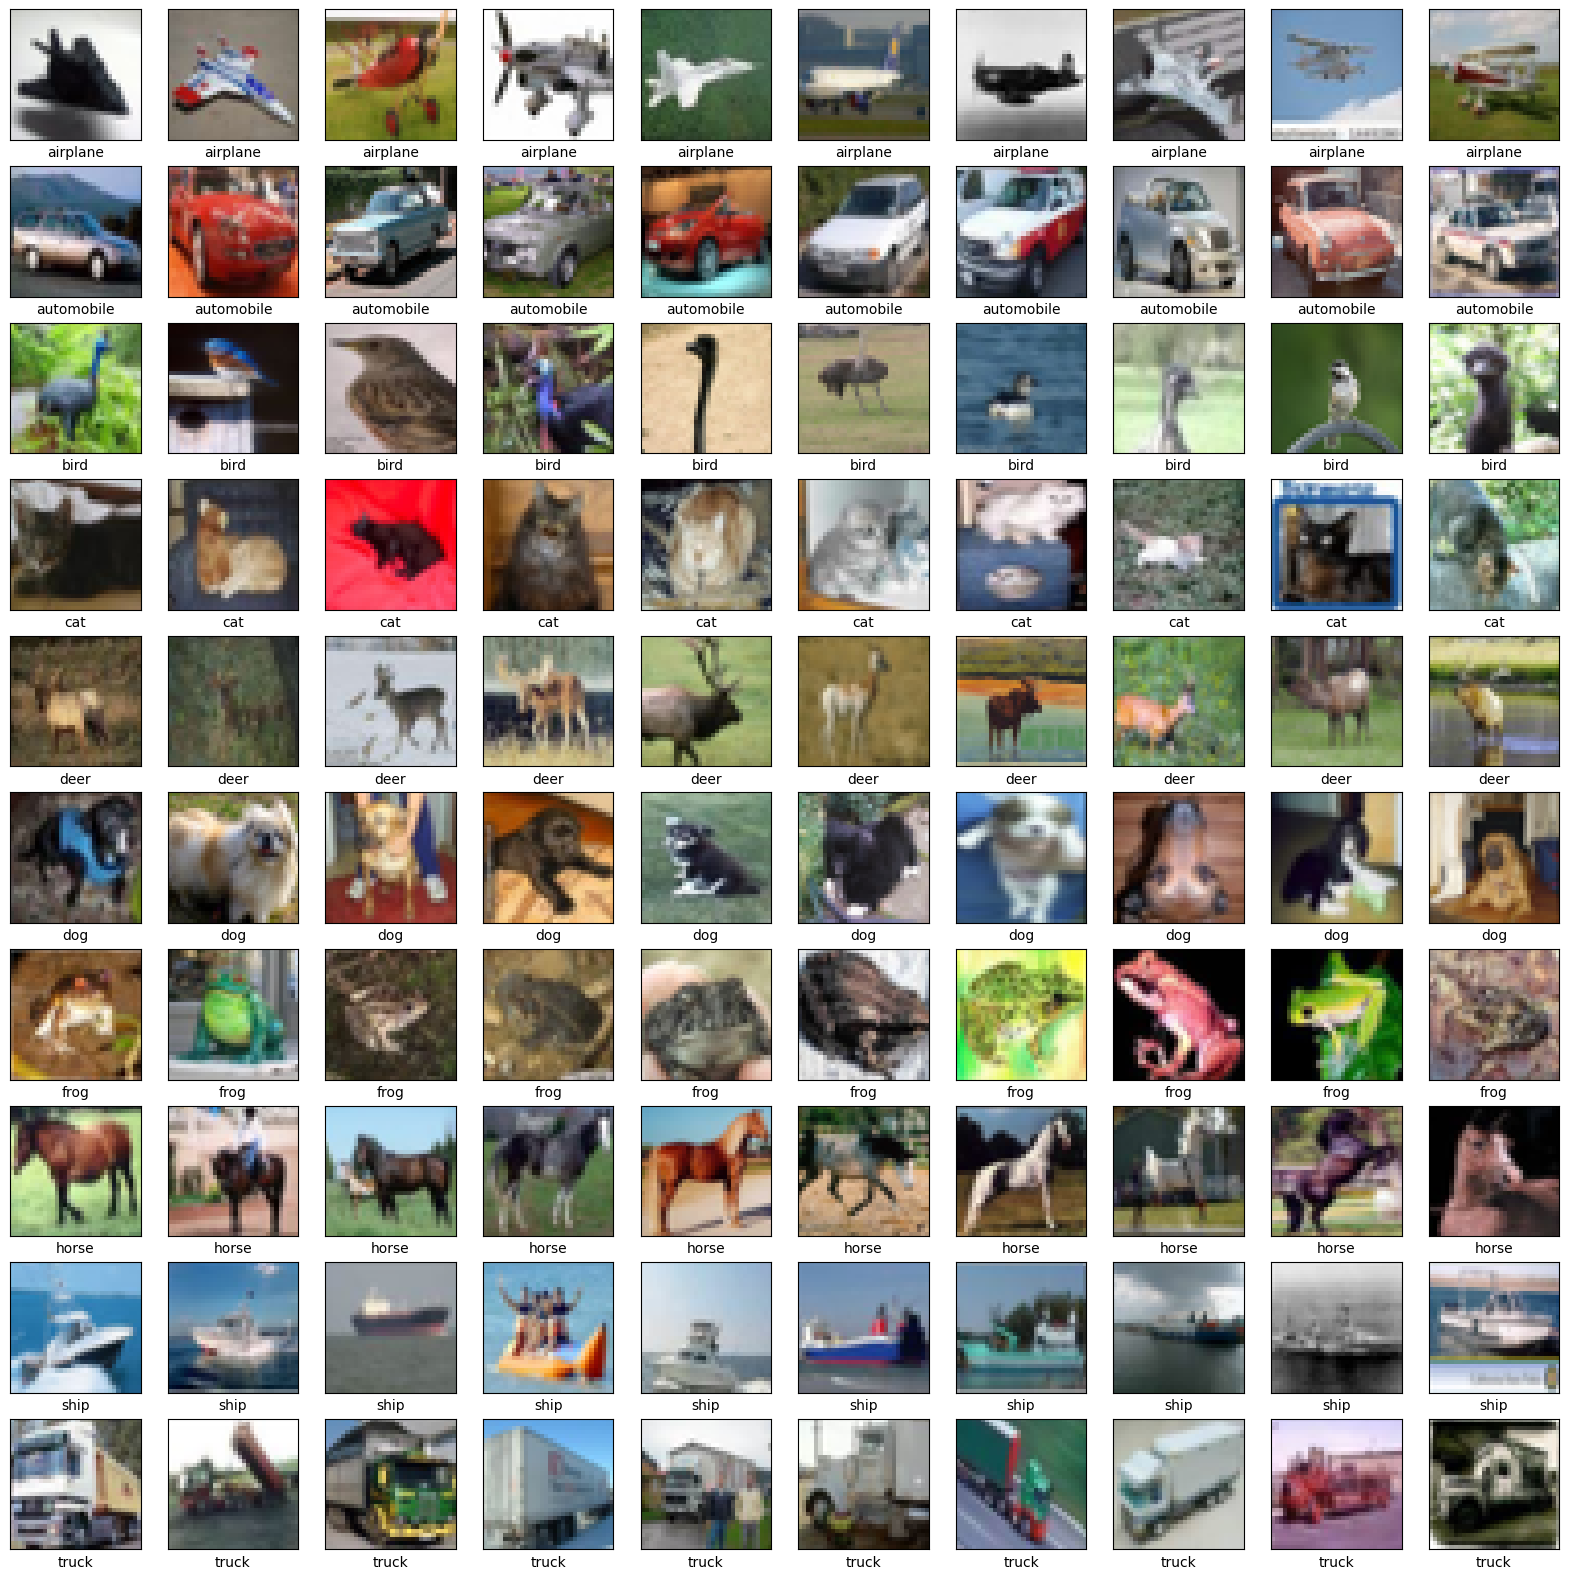

In [13]:
import numpy as np
import matplotlib.pyplot as plt

def displayImage(images, labels, nCols=10):
    """Displays images with labels (nCols per row)"""
    nRows = np.ceil(len(labels)/nCols).astype('int') # number of rows
    plt.figure(figsize=(2*nCols,2*nRows)) # figure size
    for i in range(len(labels)):
        plt.subplot(nRows,nCols,i+1)
        plt.xticks([])
        plt.yticks([])
        plt.grid(False)
        plt.imshow(images[i])
        plt.xlabel(str(labels[i]), fontsize=10)
    plt.show()
    return

k = 10
first_ten_indices_per_class = []
for class_label in range(10):
    indices = np.where(y_train == class_label)[0][:k]
    first_ten_indices_per_class.extend(indices)

images = X_train[first_ten_indices_per_class]
labels = [classes[c[0]] for c in y_train[first_ten_indices_per_class]]

SHOW_IMAGES = True # change to True to see images
if SHOW_IMAGES:
    displayImage(images, labels, k)

## Create Model [15 Points]

In the code cell below specify the code to create, compile and display the summary of a convolution neural network model that meets the following criterion: The validation accuracy of your model must be at least 0.85 by epoch 40 when the model is trained with 10% of the training samples reserved for validation.

In [14]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Define Data Augmentation (Outside Model)
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

# Define Improved CNN Model
model = keras.Sequential([
    layers.Input(shape=(32,32,3)),  # Explicit input layer

    # Apply Data Augmentation Here (Preprocessing Step)
    data_augmentation,

    # First Convolutional Block
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2,2)),
    layers.Dropout(0.3),

    # Second Convolutional Block
    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2,2)),
    layers.Dropout(0.4),

    # Third Convolutional Block
    layers.Conv2D(256, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(256, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2,2)),
    layers.Dropout(0.4),

    # Fully Connected Layers
    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.6),
    layers.Dense(10, activation='softmax')
])

# Compile the model with a reduced learning rate
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Display model summary
model.summary()


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_2 (Sequential)       │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │     2,097,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 512)            │         2,04

 Total params: 3,253,834 (12.41 MB)

 Trainable params: 3,251,018 (12.40 MB)

 Non-trainable params: 2,816 (11.00 KB)

## Train model [5 Points]
In the code cell below specify the code to train your model.

In [17]:
from tensorflow.keras.callbacks import EarlyStopping

# Early stopping to prevent overfitting
early_stopping = EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)

# Train the model for 40 epochs with 10% of training data reserved for validation
history = model.fit(
    X_train, y_train,
    epochs=40,  
    validation_split=0.1,
    batch_size=64,
    verbose=1,
    callbacks=[early_stopping]
)

# Save the trained model
model.save('cifar10_cnn.keras')


Epoch 1/40
704/704 ━━━━━━━━━━━━━━━━━━━━ 160s 227ms/step - accuracy: 0.3239 - loss: 2.1607 - val_accuracy: 0.4356 - val_loss: 1.6692
Epoch 2/40
704/704 ━━━━━━━━━━━━━━━━━━━━ 160s 227ms/step - accuracy: 0.4693 - loss: 1.5584 - val_accuracy: 0.5108 - val_loss: 1.4215
Epoch 3/40
704/704 ━━━━━━━━━━━━━━━━━━━━ 164s 234ms/step - accuracy: 0.5438 - loss: 1.3266 - val_accuracy: 0.5456 - val_loss: 1.3795
Epoch 4/40
704/704 ━━━━━━━━━━━━━━━━━━━━ 206s 292ms/step - accuracy: 0.5924 - loss: 1.1534 - val_accuracy: 0.5488 - val_loss: 1.4062
Epoch 5/40
704/704 ━━━━━━━━━━━━━━━━━━━━ 165s 235ms/step - accuracy: 0.6356 - loss: 1.0365 - val_accuracy: 0.6734 - val_loss: 0.9347
Epoch 6/40
704/704 ━━━━━━━━━━━━━━━━━━━━ 167s 237ms/step - accuracy: 0.6640 - loss: 0.9544 - val_accuracy: 0.6272 - val_loss: 1.1076
Epoch 7/40
704/704 ━━━━━━━━━━━━━━━━━━━━ 167s 237ms/step - accuracy: 0.6843 - loss: 0.9051 - val_accuracy: 0.7298 - val_loss: 0.7860
Epoch 8/40
704/704 ━━━━━━━━━━━━━━━━━━━━ 164s 233ms/step - accuracy: 0.7033 -

## Check for over-fitting [5 Points]
In the code cell below plot training and validation accuracy against epochs to check for over-fitting

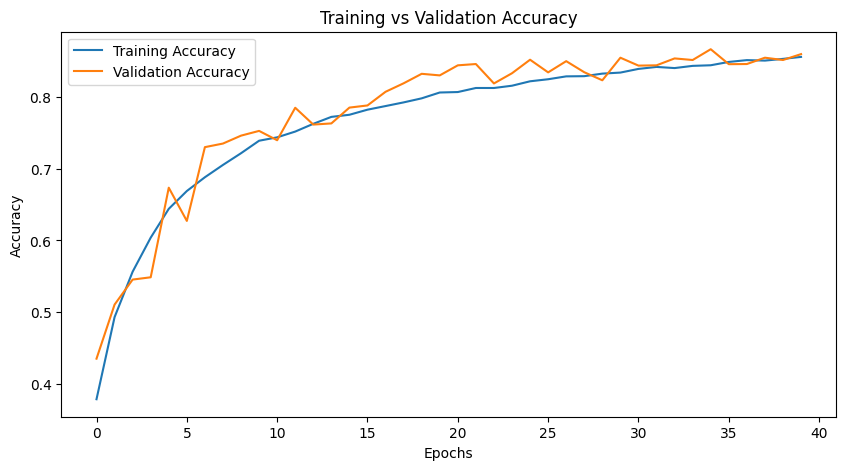

In [18]:
import matplotlib.pyplot as plt



# Plot training & validation accuracy
plt.figure(figsize=(10, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training vs Validation Accuracy')
plt.show()



## Evaluate trained model [5 Points]
In the code cell below specify your code to evaluate your trained model on the test samples. Display your classification report with metrics rounded to 4 decimal places.

In [19]:
from sklearn.metrics import classification_report
import numpy as np

# Evaluate on test set
y_pred = model.predict(X_test)
y_pred_labels = np.argmax(y_pred, axis=1)  # Convert probabilities to class labels

# Display classification report
report = classification_report(y_test, y_pred_labels, digits=4)
print(report)

313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 33ms/step
              precision    recall  f1-score   support

           0     0.8735    0.8770    0.8752      1000
           1     0.9290    0.9420    0.9355      1000
           2     0.8567    0.7950    0.8247      1000
           3     0.7980    0.7110    0.7520      1000
           4     0.8713    0.7990    0.8336      1000
           5     0.8353    0.7810    0.8072      1000
           6     0.7814    0.9510    0.8579      1000
           7     0.8814    0.9070    0.8940      1000
           8     0.9363    0.9110    0.9235      1000
           9     0.8645    0.9440    0.9025      1000

    accuracy                         0.8618     10000
   macro avg     0.8627    0.8618    0.8606     10000
weighted avg     0.8627    0.8618    0.8606     10000



## Display misclassified images [5 Points]
In the code cell below specify your code to display the first 20 misclassified test images. For each misclassified image specify (*y_true*, *y_pred*, *prob*), where *y_true* and *y_pred* are the true and predicted class labels, respectively, and *prob* is the predicted probability that the image belongs to class *y_pred*.   

313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 34ms/step


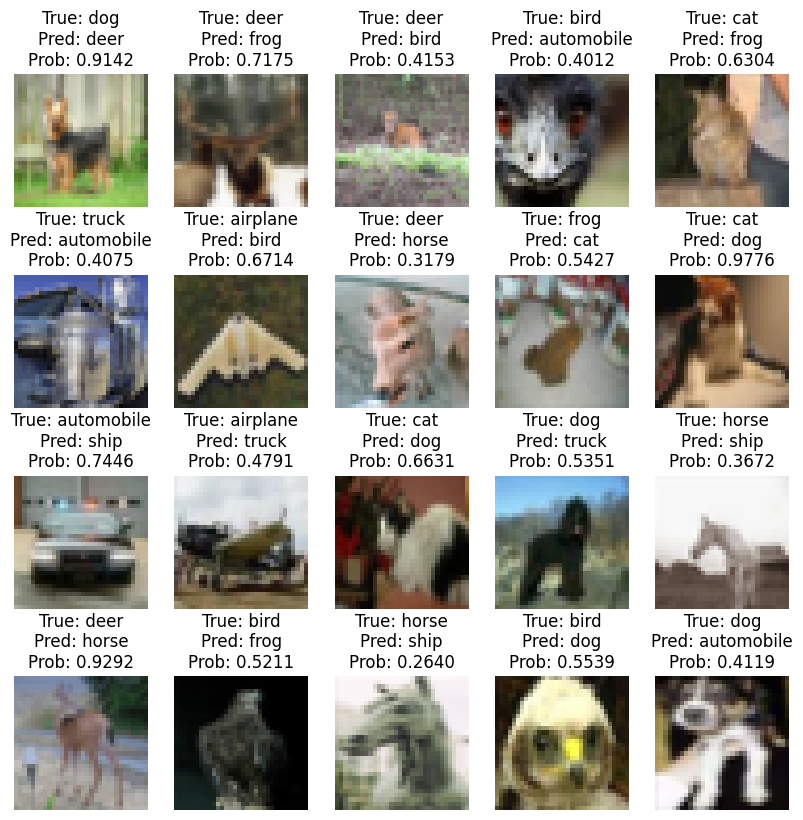

In [20]:
import numpy as np
import matplotlib.pyplot as plt

# Define CIFAR-10 class labels
classes = ['airplane', 'automobile', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck']

# Get model predictions
y_pred = model.predict(X_test)
y_pred_labels = np.argmax(y_pred, axis=1)

# Identify misclassified images
misclassified_indices = np.where(y_pred_labels != y_test.flatten())[0]

# Display first 20 misclassified images
plt.figure(figsize=(10, 10))
for i, idx in enumerate(misclassified_indices[:20]):
    plt.subplot(4, 5, i+1)
    plt.imshow(X_test[idx])
    plt.axis('off')

    # Fix: Ensure class names are defined
    true_label = classes[y_test[idx][0]]  # True label
    pred_label = classes[y_pred_labels[idx]]  # Predicted label
    prob = np.max(y_pred[idx])  # Probability of predicted label

    plt.title(f"True: {true_label}\nPred: {pred_label}\nProb: {prob:.4f}")

plt.show()
